In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
BASE_URL = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_{}.csv"
DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

years = range(2000, 2024)

dfs = []
for y in years:
    url = BASE_URL.format(y)
    path = f"{DATA_DIR}/atp_matches_{y}.csv"
    df = pd.read_csv(url)
    df.to_csv(path, index=False)   # save local copy
    print("Loaded", y, df.shape)
    df["year"] = y
    dfs.append(df)

matches = pd.concat(dfs, ignore_index=True)
matches.shape

Loaded 2000 (3378, 49)
Loaded 2001 (3307, 49)
Loaded 2002 (3213, 49)
Loaded 2003 (3218, 49)
Loaded 2004 (3288, 49)
Loaded 2005 (3264, 49)
Loaded 2006 (3267, 49)
Loaded 2007 (3192, 49)
Loaded 2008 (3123, 49)
Loaded 2009 (3085, 49)
Loaded 2010 (3030, 49)
Loaded 2011 (3015, 49)
Loaded 2012 (3009, 49)
Loaded 2013 (2944, 49)
Loaded 2014 (2901, 49)
Loaded 2015 (2943, 49)
Loaded 2016 (2941, 49)
Loaded 2017 (2911, 49)
Loaded 2018 (2897, 49)
Loaded 2019 (2806, 49)
Loaded 2020 (1462, 49)
Loaded 2021 (2733, 49)
Loaded 2022 (2917, 49)
Loaded 2023 (2986, 49)


(71830, 50)

In [6]:
cols = [
    # match metadata
    "tourney_date", "surface", "tourney_level", 
    "best_of", "round",
    
    # rankings + ages
    "winner_rank", "loser_rank",
    "winner_age", "loser_age",
    
    # essential stats
    "w_ace", "l_ace",
    "w_df", "l_df",
    "w_bpSaved", "l_bpSaved",
    
    "year"
]

df = matches[cols].copy()
df.head()

,tourney_date,surface,tourney_level,best_of,round,winner_rank,loser_rank,winner_age,loser_age,w_ace,l_ace,w_df,l_df,w_bpSaved,l_bpSaved,year
0,20000110,Hard,A,3,R32,11.0,63.0,21.7,31.1,18.0,7.0,4.0,8.0,3.0,4.0,2000
1,20000110,Hard,A,3,R32,211.0,49.0,24.5,24.3,5.0,5.0,3.0,10.0,5.0,3.0,2000
2,20000110,Hard,A,3,R32,48.0,59.0,21.3,26.5,0.0,0.0,0.0,6.0,1.0,7.0,2000
3,20000110,Hard,A,3,R32,45.0,61.0,19.9,18.4,5.0,11.0,1.0,2.0,0.0,6.0,2000
4,20000110,Hard,A,3,R32,167.0,34.0,27.3,23.7,1.0,8.0,2.0,8.0,6.0,5.0,2000


In [7]:
import random
random.seed(42)

rows = []

for _, row in df.iterrows():
    
    if random.random() < 0.5:
        p1_rank = row["winner_rank"]
        p2_rank = row["loser_rank"]
        p1_age = row["winner_age"]
        p2_age = row["loser_age"]
        p1_ace = row["w_ace"]
        p2_ace = row["l_ace"]
        p1_df = row["w_df"]
        p2_df = row["l_df"]
        p1_bp = row["w_bpSaved"]
        p2_bp = row["l_bpSaved"]
        y = 1
    else:
        p1_rank = row["loser_rank"]
        p2_rank = row["winner_rank"]
        p1_age = row["loser_age"]
        p2_age = row["winner_age"]
        p1_ace = row["l_ace"]
        p2_ace = row["w_ace"]
        p1_df = row["l_df"]
        p2_df = row["w_df"]
        p1_bp = row["l_bpSaved"]
        p2_bp = row["w_bpSaved"]
        y = 0
    
    rows.append({
        # metadata
        "surface": row["surface"],
        "tourney_level": row["tourney_level"],
        "best_of": row["best_of"],
        "round": row["round"],
        "year": row["year"],

        # numeric differences
        "rank_diff": p1_rank - p2_rank,
        "age_diff": p1_age - p2_age,
        "ace_diff": p1_ace - p2_ace,
        "df_diff": p1_df - p2_df,
        "bp_saved_diff": p1_bp - p2_bp,

        # raw values
        "p1_rank": p1_rank,
        "p2_rank": p2_rank,
        "p1_age": p1_age,
        "p2_age": p2_age,

        "y": y
    })

data = pd.DataFrame(rows)
data.head()

,surface,tourney_level,best_of,round,year,rank_diff,age_diff,ace_diff,df_diff,bp_saved_diff,p1_rank,p2_rank,p1_age,p2_age,y
0,Hard,A,3,R32,2000,52.0,9.4,-11.0,4.0,1.0,63.0,11.0,31.1,21.7,0
1,Hard,A,3,R32,2000,162.0,0.2,0.0,-7.0,2.0,211.0,49.0,24.5,24.3,1
2,Hard,A,3,R32,2000,-11.0,-5.2,0.0,-6.0,-6.0,48.0,59.0,21.3,26.5,1
3,Hard,A,3,R32,2000,-16.0,1.5,-6.0,-1.0,-6.0,45.0,61.0,19.9,18.4,1
4,Hard,A,3,R32,2000,-133.0,-3.6,7.0,6.0,-1.0,34.0,167.0,23.7,27.3,0


In [8]:
cat_cols = ["surface", "tourney_level", "round", "best_of"]

data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
data_encoded.head()

,year,rank_diff,age_diff,ace_diff,df_diff,bp_saved_diff,p1_rank,p2_rank,p1_age,p2_age,...,round_ER,round_F,round_QF,round_R128,round_R16,round_R32,round_R64,round_RR,round_SF,best_of_5
0,2000,52.0,9.4,-11.0,4.0,1.0,63.0,11.0,31.1,21.7,...,False,False,False,False,False,True,False,False,False,False
1,2000,162.0,0.2,0.0,-7.0,2.0,211.0,49.0,24.5,24.3,...,False,False,False,False,False,True,False,False,False,False
2,2000,-11.0,-5.2,0.0,-6.0,-6.0,48.0,59.0,21.3,26.5,...,False,False,False,False,False,True,False,False,False,False
3,2000,-16.0,1.5,-6.0,-1.0,-6.0,45.0,61.0,19.9,18.4,...,False,False,False,False,False,True,False,False,False,False
4,2000,-133.0,-3.6,7.0,6.0,-1.0,34.0,167.0,23.7,27.3,...,False,False,False,False,False,True,False,False,False,False


In [12]:
# remove all rows that have missing values
print("Before dropna:", data_encoded.shape)
data_encoded = data_encoded.dropna()
print("After dropna:", data_encoded.shape)

Before dropna: (71830, 28)
After dropna: (64985, 28)


In [13]:
train = data_encoded[data_encoded["year"] <= 2015]
val   = data_encoded[(data_encoded["year"] >= 2016) & (data_encoded["year"] <= 2017)]
test  = data_encoded[data_encoded["year"] >= 2018]

X_train = train.drop(columns=["y", "year"])
y_train = train["y"]

X_val = val.drop(columns=["y", "year"])
y_val = val["y"]

X_test = test.drop(columns=["y", "year"])
y_test = test["y"]

X_train.shape, X_val.shape, X_test.shape

((44254, 26), (5682, 26), (15049, 26))

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [15]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

log_reg.fit(X_train_s, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [16]:
def evaluate(model, X, y, name=""):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC-AUC: {auc:.3f}")


evaluate(log_reg, X_train_s, y_train, "TRAIN")
evaluate(log_reg, X_val_s, y_val, "VALIDATION")
evaluate(log_reg, X_test_s, y_test, "TEST")


=== TRAIN ===
Accuracy: 0.733
F1-score: 0.733
ROC-AUC: 0.797

=== VALIDATION ===
Accuracy: 0.727
F1-score: 0.728
ROC-AUC: 0.792

=== TEST ===
Accuracy: 0.717
F1-score: 0.715
ROC-AUC: 0.780


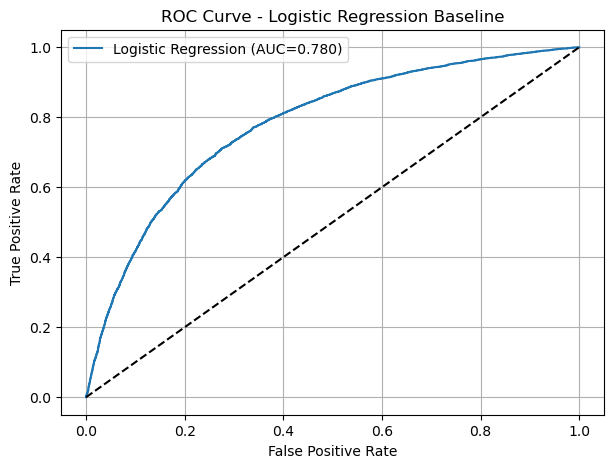

In [17]:
from sklearn.metrics import roc_curve

y_proba_test = log_reg.predict_proba(X_test_s)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba_test)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_test):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Baseline")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
coef = log_reg.coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coef
}).sort_values(by="coef", key=abs, ascending=False)

coef_df.head(15)

,feature,coef
2,ace_diff,0.692594
4,bp_saved_diff,-0.551554
3,df_diff,-0.519598
0,rank_diff,-0.339407
6,p2_rank,0.234826
5,p1_rank,-0.226709
14,tourney_level_G,0.110206
25,best_of_5,-0.102606
1,age_diff,-0.044561
8,p2_age,0.033194


In [19]:
data_encoded.to_csv("../data/final_dataset.csv", index=False)

In [20]:
import joblib

joblib.dump(log_reg, "../models/log_reg.pkl")

print("Models saved!")

Models saved!
